In [171]:

import cv2
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import PIL.Image

In [172]:
input_video_path = "two_channel.mp4"
output_csv_path = "single_results.csv"

In [173]:
# 1. Initialize Video Capture
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()

# List to store data for each frame
data_log = []

frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
display_every_n_frames = 100

cx = frame_width // 2
cy = frame_height // 2

window_size = 220

# Centered square crop window with bounds clamped to the frame
half_window = window_size // 2
x1 = cx - half_window
y1 = cy - half_window - 80
x2 = cx + half_window
y2 = cy + half_window - 80

# ROI (bottom-right of cropped frame)
roi_size = 50
prev_brightness = None
change_threshold = 10
brightness_frames = []



In [174]:
def split_contour(gradient):
    # Returns two contour parts after splitting along the best triangle edge.
    r1, r2 = 8, 128
    c = cv2.findNonZero(gradient)
    if c is None or len(c) < 3:
        return gradient.copy(), np.zeros_like(gradient)

    triangle = cv2.minEnclosingTriangle(c)[1]
    if triangle is None:
        return gradient.copy(), np.zeros_like(gradient)

    triangle = np.intp(triangle)
    score = np.zeros(3)
    for i in range(0, 3):
        grad_temp = gradient.copy()
        cv2.line(grad_temp, triangle[i][0], triangle[(i + 1) % 3][0], 0, 6)
        score[i] = cv2.countNonZero(grad_temp)

    idx = int(np.argmin(score))
    grad_work = gradient.copy()
    cv2.line(grad_work, triangle[idx][0], triangle[(idx + 1) % 3][0], 0, r1)
    g1 = grad_work.copy()
    cv2.line(grad_work, triangle[idx][0], triangle[(idx + 1) % 3][0], 0, r2)
    g2 = cv2.bitwise_xor(g1, grad_work)
    return (g1, g2)

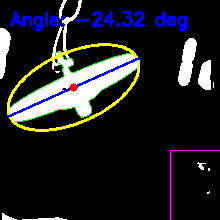


Success! Data saved to: single_results.csv


In [175]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped = frame[y1:y2, x1:x2]
    
    # 1. Grayscale and basic threshold
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    
    # 2. ROI Brightness detection
    h, w = binary.shape[:2]
    rx1, ry1 = max(w - roi_size, 0), max(h - roi_size - 20, 0)
    current_brightness = cv2.mean(binary[ry1:h, rx1:w])[0]

    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)
    prev_brightness = current_brightness

    # 3. Disconnect thin strings/sticks using Morphological Opening
    # A 7x7 circular kernel removes features thinner than 7 pixels
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 4. Find contours and strictly keep only the largest one
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    frame_data = {
        "frame": frame_count, "timestamp_sec": frame_count / fps, "detected": False,
        "line_point_x": None, "line_point_y": None, "line_dir_x": None, "line_dir_y": None,
        "line_angle_deg": None, "longest_width_px": None
    }

    overlay = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR) # Draw over the binary to see what's retained
    
    if contours:
        best_cnt = max(contours, key=cv2.contourArea)
        
        # Only process if the blob is substantial
        if cv2.contourArea(best_cnt) > 200:
            # Create an isolated mask strictly containing the largest filled shape
            isolated_disk = np.zeros_like(gray)
            cv2.drawContours(isolated_disk, [best_cnt], -1, 255, cv2.FILLED)
            
            # Extract (x,y) coordinates of all pixels forming the "mass"
            y_idx, x_idx = np.nonzero(isolated_disk)
            pts = np.column_stack((x_idx, y_idx)).astype(np.float32)
            
            if len(pts) >= 10:
                # 5. PCA Analysis: Finds the true centroid and structural axes based on pixel mass
                mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts, mean=None)
                cx, cy = mean[0, 0], mean[0, 1]
                
                # Primary eigenvector (major axis) directions
                vx, vy = eigenvectors[0, 0], eigenvectors[0, 1]
                angle_rad = math.atan2(vy, vx)
                angle_deg = math.degrees(angle_rad)
                
                # Project pixels onto eigenvectors to calculate EXACT tight bounds
                centered = pts - mean[0]
                proj_major = np.dot(centered, eigenvectors[0])
                proj_minor = np.dot(centered, eigenvectors[1])
                
                major_len = float(proj_major.max() - proj_major.min())
                minor_len = float(proj_minor.max() - proj_minor.min())
                
                # Normalize angle for readable output
                if angle_deg > 90: angle_deg -= 180
                elif angle_deg < -90: angle_deg += 180
                
                frame_data.update({
                    "detected": True, "line_point_x": round(cx, 2), "line_point_y": round(cy, 2),
                    "line_dir_x": round(float(vx), 4), "line_dir_y": round(float(vy), 4),
                    "line_angle_deg": round(angle_deg, 2), "longest_width_px": round(major_len, 2)
                })

                # --- Visualizations ---
                cv2.drawContours(overlay, [best_cnt], -1, (0, 255, 0), 1)
                
                # Draw tight ellipse using PCA dimensions
                rx, ry = int(major_len / 2), int(minor_len / 2)
                cv2.ellipse(overlay, (int(cx), int(cy)), (rx, ry), angle_deg, 0, 360, (0, 255, 255), 2)
                
                # Draw Central Axis Line
                L = major_len / 2
                pt1 = (int(cx - vx * L), int(cy - vy * L))
                pt2 = (int(cx + vx * L), int(cy + vy * L))
                cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
                cv2.circle(overlay, (int(cx), int(cy)), 4, (0, 0, 255), -1)
                
                cv2.putText(overlay, f"Angle: {angle_deg:.2f} deg", (10, 25), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    cv2.rectangle(overlay, (rx1, ry1), (w, h), (255, 0, 255), 1)
    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    # Visualization refresh
    if frame_count % display_every_n_frames == 0:
        img = PIL.Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

# Clean up and save results
cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nSuccess! Data saved to: {output_csv_path}")

Segment 0: Frames 579 to 799, Mean Angle: 4.70
Segment 1: Frames 839 to 978, Mean Angle: 3.45
Segment 2: Frames 1018 to 1156, Mean Angle: 1.97
Segment 3: Frames 1196 to 1335, Mean Angle: -0.22
Segment 4: Frames 1375 to 1513, Mean Angle: -3.18
Segment 5: Frames 1553 to 1694, Mean Angle: -6.01
Segment 6: Frames 1734 to 1873, Mean Angle: -7.70
Segment 7: Frames 1913 to 2052, Mean Angle: -11.33
Segment 8: Frames 2092 to 2232, Mean Angle: -13.96
Segment 9: Frames 2272 to 2411, Mean Angle: -19.06


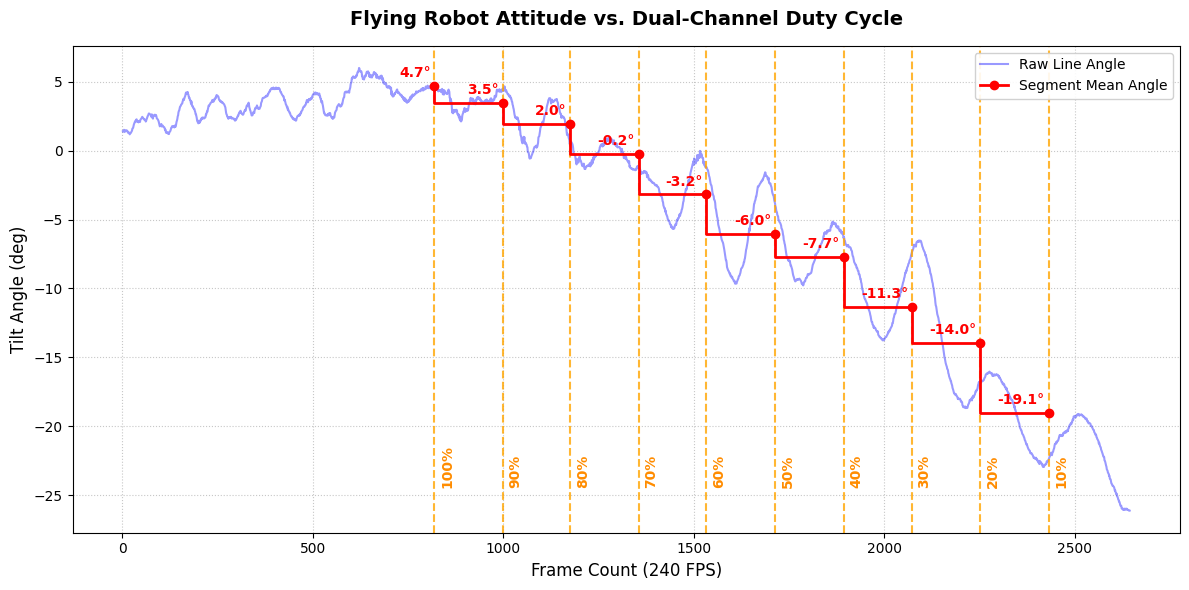

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and filter detections
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Compute segment means robustly based on actual frame values
mean_segment_angles = []
segment_buffer = 20

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer
    
    # Robust frame-based filtering (avoids Pandas index mismatch issues)
    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)]['line_angle_deg']
    mean_val = seg.mean()
    mean_segment_angles.append(mean_val)
    print(f"Segment {i}: Frames {seg_start} to {seg_end}, Mean Angle: {mean_val:.2f}")

# Plotting Configuration
plt.figure(figsize=(12, 6))

# Plot raw angles with slight transparency so annotations pop out
plt.plot(df['frame'], df['line_angle_deg'], 'b-', alpha=0.4, label='Raw Line Angle')

# Calculate dynamic y-offsets for text placement
y_min, y_max = df['line_angle_deg'].min(), df['line_angle_deg'].max()
y_range = y_max - y_min

# Plot Vertical Lines & Percentages
for i, bt in enumerate(brightness_frames):
    # Plot line without a label to remove it from the legend
    plt.axvline(bt, color='orange', linestyle='--', alpha=0.8)
    
    # Label the percentage vertically next to the line
    percentage_str = f'{100 - i*10}%'
    plt.text(bt + 15, y_min + y_range * 0.05, percentage_str, 
             color='darkorange', rotation=90, va='bottom', ha='left', 
             fontweight='bold', fontsize=10)

# Plot Step Function for Averages
plt.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre', 
         linewidth=2, markersize=6, label='Segment Mean Angle')

# Annotate each step with the exact average value
for i, (bt, mean_angle) in enumerate(zip(brightness_frames, mean_segment_angles)):
    if pd.notna(mean_angle):
        # Position the text slightly above the red marker
        plt.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°", 
                 color='red', fontweight='bold', fontsize=10, ha='right')

# Formatting and Labels
plt.title('Flying Robot Attitude vs. Dual-Channel Duty Cycle', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frame Count (240 FPS)', fontsize=12)
plt.ylabel('Tilt Angle (deg)', fontsize=12)

# Legend and Grid
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()

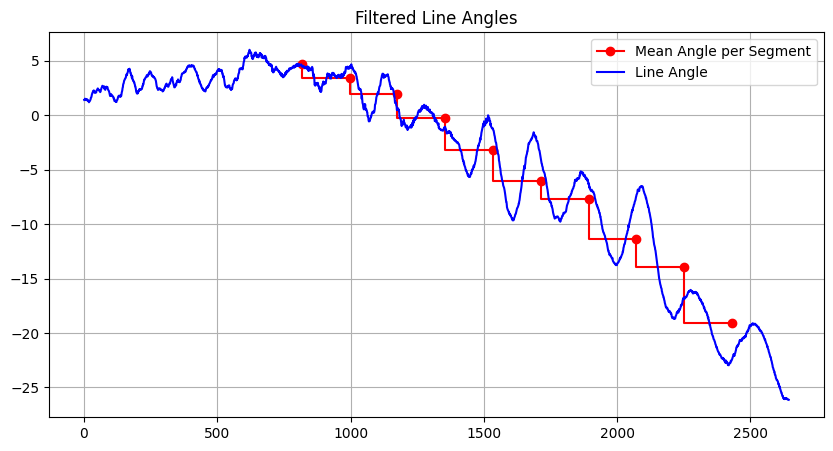

In [177]:
plt.figure(figsize=(10, 5))
plt.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre', label='Mean Angle per Segment')
plt.plot(df['frame'].values, df['line_angle_deg'].values, 'b-', label='Line Angle')
plt.title('Filtered Line Angles'); plt.legend(); plt.grid(True)
plt.show()